# Cliffordizing Trotterized Ising Model Circuits
## 1. The Physics: 1D Transverse-Field Ising Model
The Hamiltonian for a 1D chain of $n$ spins with nearest-neighbor interactions $J$ and a transverse magnetic field $h$ is defined as:
$$
    H = -J \sum_{i=0}^{n-2} Z_i Z_{i+1} - h \sum_{i=0}^{n-1} X_i
$$
where $Z_i$ and $X_i$ are the Pauli-Z and Pauli-X operators acting on qubit $i$.

### Time Evolution & Trotterization
To simulate the evolution $U(t) = e^{-iHt}$, we cannot implement $e^{-iHt}$ directly because the $ZZ$ and $X$ terms do not commute. We use the Lie-Trotter product formula (first order) to approximate it by slicing time $t$ into $N$ small steps of size $\Delta t = t/N$:
$$
    e^{-iHt} \approx \left( e^{-i H_{ZZ} \Delta t} e^{-i H_X \Delta t} \right)^N
$$
where:
* $e^{-i (-h X) \Delta t} = R_x(2h \Delta t)$
* $e^{-i (-J ZZ) \Delta t}$ is implemented as `CX` $\rightarrow$ `R_z(2J \Delta t)` $\rightarrow$ `CX`.

In [42]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import IGate, XGate, YGate, ZGate
from qiskit.quantum_info import random_clifford

# =====================================================================
# 1. The Physics: 1D Transverse-Field Ising Model
# =====================================================================
n_qubits = 6
J = 0.2   # Interaction strength
h = 1.2   # Transverse field
dt = 0.15 # Small time step

def build_trotter_ising(n_qubits, J, h, total_time, trotter_steps):
    """Constructs a First-order Trotter circuit for the 1D Ising Model."""
    qc = QuantumCircuit(n_qubits)
    dt = total_time / trotter_steps
    
    for _ in range(trotter_steps):
        # ZZ interactions (Interaction Layer)
        for i in range(n_qubits - 1):
            angle = 2 * J * dt
            qc.cx(i, i+1)
            qc.rz(angle, i+1)
            qc.cx(i, i+1)
        
        # Transverse X field (Single-qubit Layer)
        for i in range(n_qubits):
            angle = 2 * h * dt
            qc.rx(angle, i)
            
        qc.barrier() # Optional: useful for visualizing layers
        
    return qc

### 2. The Method: Cliffordization (Scalable Proxy Circuits)
**Concept:** A "Proxy Circuit" has the exact same multi-qubit structure (entanglement map) as your target circuit but replaces hard-to-simulate gates (like non-Clifford rotations) with efficiently simulatable Clifford gates.

#### Implementation:
According to [Merkel et al.](https://arxiv.org/abs/2503.05943), to properly estimate performance under the **Pauli Twirling Assumption (PTA)**, you should use **Randomized Cliffordization**.

* **2-Qubit Gates:** Keep them exactly as they are (assuming they are Cliffords, like CNOT).

* **1-Qubit Gates:** Replace every generic single-qubit gate (like Rx, Rz) with a **randomly sampled single-qubit Clifford gate**.

This creates a statistical ensemble of circuits whose average fidelity tracks the fidelity of your target application.

#### Code: Randomized Cliffordizer

In [43]:
# =====================================================================
# 2. The Method: Cliffordization (Scalable Proxy Circuits)
# =====================================================================
def cliffordize_circuit(qc, num_proxies=5):
    """
    Generates a list of 'Clifford Proxy' circuits.
    Structure: Same CNOTs as target.
    1-Qubit Gates: Replaced by random 1-qubit Cliffords.
    """
    proxies = []
    
    for _ in range(num_proxies):
        proxy = QuantumCircuit(*qc.qregs, *qc.cregs)
        
        for instr in qc.data:
            op = instr.operation
            qubits = instr.qubits
            
            if op.name in ['cx', 'barrier']:
                # Preserve the entanglement structure
                proxy.append(op, qubits)
            elif len(qubits) == 1:
                # Replace ANY single-qubit gate with a Random Clifford
                rc = random_clifford(1).to_circuit()
                proxy.compose(rc, qubits=qubits, inplace=True)
            else:
                proxy.append(op, qubits)
        
        proxies.append(proxy)
        
    return proxies

### 3. The Requirement: Pauli Twirling (PTA)
The paper's guarantee—that Clifford proxy fidelity matches application fidelity—is only valid if the noise channels are Pauli-stochastic. Real hardware has coherent errors (systematic over-rotations). **Pauli Twirling** converts these coherent errors into stochastic probability errors, satisfying the assumption.

You must wrap your CNOT gates with random Paulis during execution.

#### Code: Pauli Twirling

In [44]:
def apply_pauli_twirl_viz(qc):
    """
    Manually applies Pauli Twirling for visualization.
    Wraps every CNOT in random Paulis.
    """
    twirled = QuantumCircuit(*qc.qregs)
    paulis = [IGate(), XGate(), YGate(), ZGate()]
    
    for instr in qc.data:
        op = instr.operation
        qubits = instr.qubits
        
        if op.name == 'cx':
            # 1. Pick random Paulis for Control/Target (Pre-gate)
            # We color them 'red' or distinctively in diagrams if possible, 
            # but standard drawer just shows gates.
            pc = paulis[np.random.randint(4)]
            pt = paulis[np.random.randint(4)]
            
            # Add Pre-Paulis
            twirled.append(pc, [qubits[0]])
            twirled.append(pt, [qubits[1]])
            
            # Add CNOT
            twirled.append(op, qubits)
            
            # Add Post-Paulis (For viz, we just add random ones again to show the structure)
            # In real compilation, these are calculated to correct the logic.
            # Here we just show that gates are added.
            pc_prime = paulis[np.random.randint(4)]
            pt_prime = paulis[np.random.randint(4)]
            twirled.append(pc_prime, [qubits[0]])
            twirled.append(pt_prime, [qubits[1]])
        else:
            twirled.append(op, qubits)
    return twirled


A. TARGET CIRCUIT (The Physics)
This is the exact Trotter step for the Ising model.
Notice the continuous-angle rotations (Rx, Rz). These are hard to 
simulate classically at large scales and prone to coherent hardware errors.


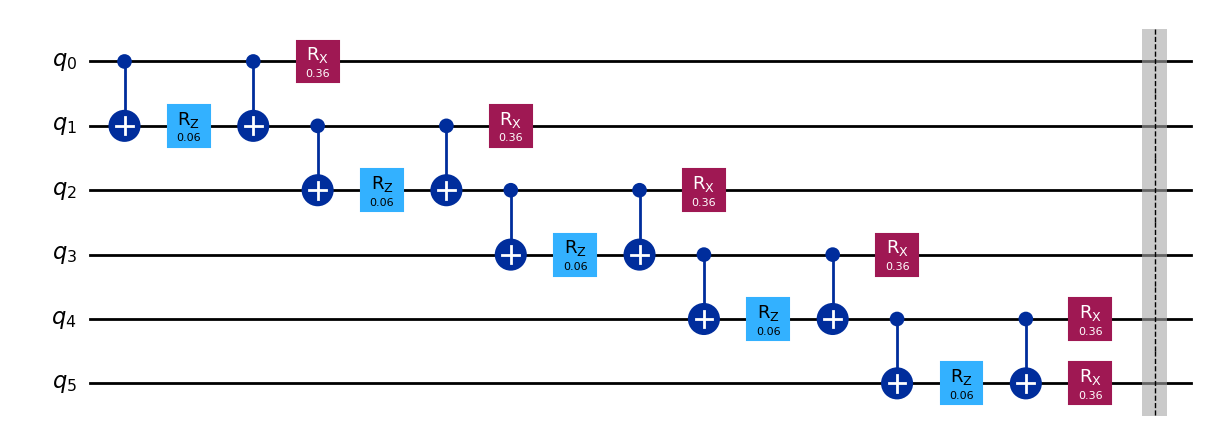


B. PROXY CIRCUIT (The Benchmark)
We preserve the exact CNOT structure (the main source of hardware error),
but replace the hard physics rotations with random 1-qubit Clifford gates.
This makes the circuit efficiently simulatable while maintaining the 
same 'entanglement footprint' as the target.


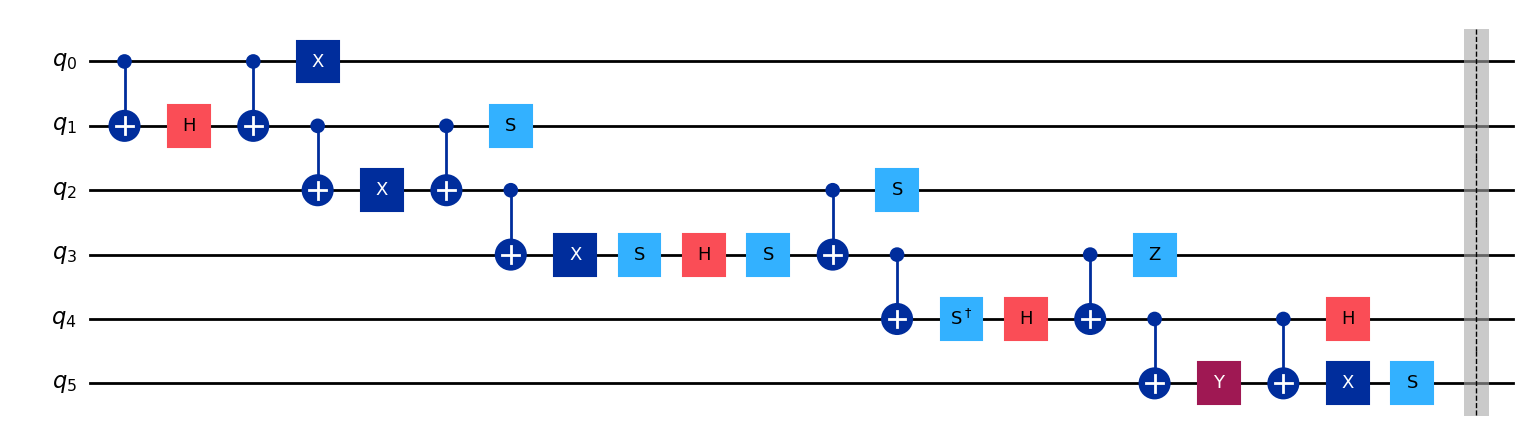


C. PAULI TWIRLED TARGET (Hardware Ready)
To guarantee the Clifford Proxy accurately estimates the Target, we must
satisfy the Pauli Twirling Assumption (PTA). Notice how every CNOT is now
'sandwiched' by random Pauli gates. This forces coherent errors to 
manifest as stochastic Pauli noise.


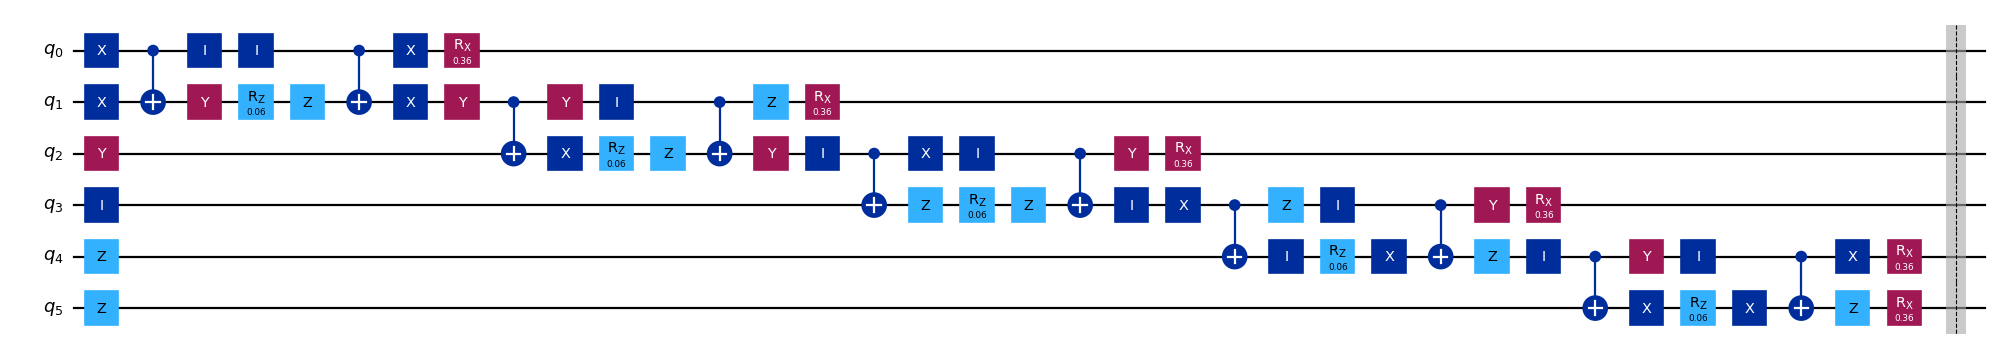

In [45]:
# =====================================================================
# Generation & Visualization
# =====================================================================

# --- A. The Target (Ising) ---
target_circ = build_trotter_ising(n_qubits, J, h, dt, trotter_steps=1)
print("\n" + "="*50)
print("A. TARGET CIRCUIT (The Physics)")
print("="*50)
print("This is the exact Trotter step for the Ising model.")
print("Notice the continuous-angle rotations (Rx, Rz). These are hard to ")
print("simulate classically at large scales and prone to coherent hardware errors.")
display(target_circ.draw('mpl', style='iqp', fold=-1))

# --- B. The Proxy (Cliffordized) ---
proxies_list = cliffordize_circuit(target_circ, num_proxies=5)
proxy_circ = proxies_list[0] 
print("\n" + "="*50)
print("B. PROXY CIRCUIT (The Benchmark)")
print("="*50)
print("We preserve the exact CNOT structure (the main source of hardware error),")
print("but replace the hard physics rotations with random 1-qubit Clifford gates.")
print("This makes the circuit efficiently simulatable while maintaining the ")
print("same 'entanglement footprint' as the target.")
display(proxy_circ.draw('mpl', style='iqp', fold=-1))

# --- C. The Twirled Target (Noisy Compilation) ---
twirled_circ = apply_pauli_twirl_viz(target_circ)
print("\n" + "="*50)
print("C. PAULI TWIRLED TARGET (Hardware Ready)")
print("="*50)
print("To guarantee the Clifford Proxy accurately estimates the Target, we must")
print("satisfy the Pauli Twirling Assumption (PTA). Notice how every CNOT is now")
print("'sandwiched' by random Pauli gates. This forces coherent errors to ")
print("manifest as stochastic Pauli noise.")
display(twirled_circ.draw('mpl', style='iqp', scale=0.8, fold=-1))

_Note: In Qiskit's ecosystem, `qiskit-research` or `qiskit-ibm-runtime` often includes a `PauliTwirling` transpiler pass which is more robust than a manual loop._

### 4. Comparison & Benchmarking Workflow
This script simulates the entire experiment. It compares the **Fidelity** of the actual Ising simulation against the **Average Fidelity** of the Clifford Proxies.

Running Benchmark...
Depth 01 | Target Fidelity: 0.9277 | Proxy Estimate: 0.9692
Depth 02 | Target Fidelity: 0.8608 | Proxy Estimate: 0.9459
Depth 03 | Target Fidelity: 0.7993 | Proxy Estimate: 0.9295
Depth 04 | Target Fidelity: 0.7427 | Proxy Estimate: 0.9052
Depth 05 | Target Fidelity: 0.6904 | Proxy Estimate: 0.8735
Depth 06 | Target Fidelity: 0.6423 | Proxy Estimate: 0.8428


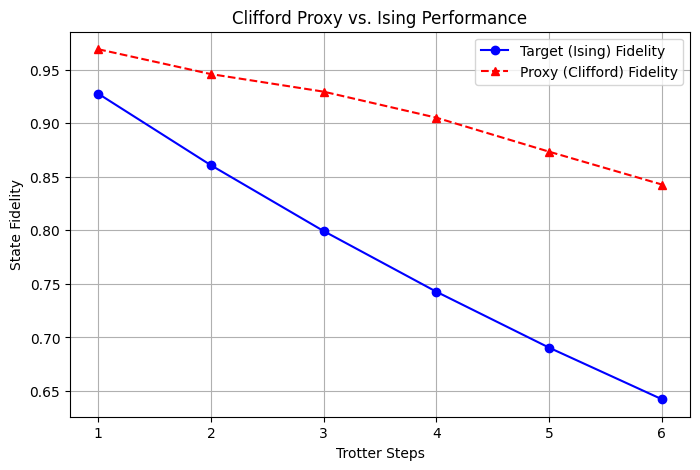

In [46]:
import matplotlib.pyplot as plt
from qiskit import transpile
from qiskit.quantum_info import Statevector, state_fidelity
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# --- Simulation & Benchmarking ---
n_qubits = 6
J, h = 0.2, 1.2
total_time = 1.0
steps_list = [1, 2, 3, 4, 5, 6]

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.01, 2), ['cx'])
ideal_sim = AerSimulator(method="statevector")

noisy_sim = AerSimulator(
    method="density_matrix",
    noise_model=noise_model
)

target_fidelities = []
proxy_fidelities = []

print("Running Benchmark...")

for steps in steps_list:
    # --- TARGET (Ising) ---
    target_qc = build_trotter_ising(n_qubits, J, h, total_time, steps)
    
    # Ideal state
    t_ideal = target_qc.copy()
    t_ideal.save_statevector()
    sv_ideal = ideal_sim.run(transpile(t_ideal, ideal_sim)).result().get_statevector()
    
    # Noisy density matrix
    t_noisy = target_qc.copy()
    t_noisy.save_density_matrix()
    res_t = noisy_sim.run(transpile(t_noisy, noisy_sim)).result()
    rho_target = res_t.data(0)['density_matrix'] # Retrieve from result data dict
    
    target_fidelities.append(state_fidelity(sv_ideal, rho_target))
    
    # --- PROXIES (Clifford) ---
    proxies = cliffordize_circuit(target_qc, num_proxies=5)
    batch_fids = []
    for p in proxies:
        p_ideal = p.copy()
        p_ideal.save_statevector()
        sv_p_ideal = ideal_sim.run(transpile(p_ideal, ideal_sim)).result().get_statevector()
        
        p_noisy = p.copy()
        p_noisy.save_density_matrix()
        res_p = noisy_sim.run(transpile(p_noisy, noisy_sim)).result()
        rho_p_noisy = res_p.data(0)['density_matrix']
        
        batch_fids.append(state_fidelity(sv_p_ideal, rho_p_noisy))
        
    #proxy_fidelities.append(np.mean(batch_fids))
    #print(f"Steps {steps} completed.")

    proxy_mean = np.mean(batch_fids)
    proxy_fidelities.append(proxy_mean)
    
    # NEW: Informative live-logging
    print(f"Depth {steps:02d} | Target Fidelity: {target_fidelities[-1]:.4f} | Proxy Estimate: {proxy_mean:.4f}")

# --- 4. Comparison Plot ---
plt.figure(figsize=(8, 5))
plt.plot(steps_list, target_fidelities, 'bo-', label='Target (Ising) Fidelity')
plt.plot(steps_list, proxy_fidelities, 'r^--', label='Proxy (Clifford) Fidelity')
plt.xlabel('Trotter Steps')
plt.ylabel('State Fidelity')
plt.title('Clifford Proxy vs. Ising Performance')
plt.legend()
plt.grid(True)
plt.show()

### 5. Application: Estimating Observables (Mitigation)
The user asked to compare "time evolution of observables".
* **The Problem:** The Clifford proxy returns random bitstrings, so it cannot directly predict the Magnetization $\langle Z \rangle$ of the Ising model.
* **The Solution:** Use the Proxy Fidelity to error-correct the Ising Observable.

If you measure a magnetization $M_{noisy}$ from your Ising circuit, and your Clifford proxies estimate a fidelity $F_{proxy}$, you can estimate the true magnetization $M_{true}$ using the depolarization model:
$$
    M_{mitigated} \approx \frac{M_{noisy}}{F_{proxy}}
$$
This is how you use the benchmark to improve the application result.